In [7]:
import milaDS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import DS 
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import re

In [8]:
def plotDS(X_data, Y_data, V_disp, threshold=0, scale=100, alpha_scale=1):
    # Normalize the dispersion values for color mapping
    norm = Normalize(vmin=np.min(V_disp), vmax=np.max(V_disp))

    # Create a colormap
    cmap = cm.coolwarm  # You can choose different colormaps (e.g., plt.cm.plasma)

    # Map the dispersion values to colors
    colors = cmap(norm(V_disp))

    filtered_X = X_data[V_disp >= threshold]
    filtered_Y = Y_data[V_disp >= threshold]
    filtered_dispersion_values = V_disp[V_disp >= threshold]

    # Create the plot
    fig, ax = plt.subplots(figsize=(16, 12))  # Create figure and axes

    # Scatter plot with empty circles
    scatter = ax.scatter(filtered_X, filtered_Y, s=(filtered_dispersion_values**alpha_scale)*scale, facecolors='none', edgecolors=colors, linewidth=1.5)

    # Add colorbar for reference
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)  # Specify the axes for the colorbar
    cbar.set_label('Dispersion Value')  # Label for the colorbar

    # Add labels and title
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title('Dressler-Schectman Test Visualization with Variable Edge Colors')

    # Show grid
    ax.grid()

    # Show the plot
    plt.show()

In [9]:
def to_kpc(ra, dec, z):
    
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    dist = cosmo.angular_diameter_distance(z)

    x = (ra * dist).to(u.Mpc, u.dimensionless_angles()).value

    y = (dec * dist).to(u.Mpc, u.dimensionless_angles()).value

    return x*1000,y*1000

In [10]:


def to_vel(z_gal, z_clus):

    c = const.c.value
    vel = (c*(z_gal - z_clus)/(1 + z_clus))

    return vel

In [11]:
mocks_path = "/Users/gasep/OneDrive/Escritorio/Dresler-Schetman/Data/Mocks/clean halos"

files = os.listdir(mocks_path)

# Filter .cat files
cat_files = [file for file in files if file.endswith('.cat')]

def extract_number(file_name):
    match = re.search(r'(\d+)', file_name)  # Find the number in the filename
    return int(match.group()) if match else 0  # Return the number as an integer

cat_files_sorted = sorted(cat_files, key=extract_number)
print(cat_files_sorted)

# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop through each .cat file, read into a DataFrame, and append to the list
for file in cat_files_sorted:
    file_path = os.path.join(mocks_path, file)
    df = pd.read_csv(file_path, delimiter='\t')
    dfs.append(df)

print(len(dfs))

['galaxies_clean_cluster_0.cat', 'galaxies_clean_cluster_1.cat', 'galaxies_clean_cluster_2.cat', 'galaxies_clean_cluster_3.cat', 'galaxies_clean_cluster_4.cat', 'galaxies_clean_cluster_5.cat', 'galaxies_clean_cluster_6.cat', 'galaxies_clean_cluster_7.cat', 'galaxies_clean_cluster_8.cat', 'galaxies_clean_cluster_9.cat', 'galaxies_clean_cluster_10.cat', 'galaxies_clean_cluster_11.cat', 'galaxies_clean_cluster_12.cat', 'galaxies_clean_cluster_13.cat', 'galaxies_clean_cluster_14.cat', 'galaxies_clean_cluster_15.cat', 'galaxies_clean_cluster_16.cat', 'galaxies_clean_cluster_17.cat', 'galaxies_clean_cluster_18.cat', 'galaxies_clean_cluster_19.cat', 'galaxies_clean_cluster_20.cat', 'galaxies_clean_cluster_21.cat', 'galaxies_clean_cluster_22.cat', 'galaxies_clean_cluster_23.cat', 'galaxies_clean_cluster_24.cat', 'galaxies_clean_cluster_25.cat', 'galaxies_clean_cluster_26.cat', 'galaxies_clean_cluster_27.cat', 'galaxies_clean_cluster_28.cat', 'galaxies_clean_cluster_29.cat', 'galaxies_clean_clu

In [ ]:
path = '/Users/gasep/OneDrive/Escritorio/Dresler-Schetman/Data/Galaxies/MACS0416_CLASH-VLT_MUSE_zcat.cat'

data = np.genfromtxt(path, delimiter=None, dtype=None, encoding=None, names=True)

df = 

print(data)

In [12]:
for i in range(len(dfs)):
    # Split the concatenated column into multiple columns
    split_cols = dfs[i]['# galaxyId haloId haloId_dor ra dec z_app log(m_200)'].str.split(' ', expand=True)

    # Concatenate split_cols with combined_df
    split_df = pd.concat([dfs[i], split_cols], axis=1)

    # Assign appropriate column names
    split_df.columns = ['original_col', 'galaxyId', 'haloId', 'haloId_dor', 'ra', 'dec', 'z_app', 'log(m_200)']

    # Drop the original concatenated column and unnecessary columns
    split_df = split_df.drop(columns=['original_col'])


    numeric_columns = ['galaxyId', 'haloId', 'haloId_dor', 'ra', 'dec', 'z_app', 'log(m_200)']
    split_df[numeric_columns] = split_df[numeric_columns].apply(pd.to_numeric, errors='coerce')
    dfs[i] = split_df
    


print(len(dfs))

249


In [ ]:
print(dfs[26].head())

In [27]:
df_id = 0

In [29]:
X_data = dfs[df_id].iloc[:,3].values
Y_data = dfs[df_id].iloc[:,4].values
Z_data = dfs[df_id].iloc[:,5].values
group = dfs[df_id].iloc[:,2].values


Z_clus = np.mean(Z_data);

X_Kpc, Y_Kpc = to_kpc(X_data, Y_data, Z_data)

V_data = to_vel(Z_data, Z_clus)




In [7]:
print(V_data)

[ -232990.73701006 -2200372.99927371 -1375837.80296981 ...
   487237.20439491   482660.09154492   501327.56517936]


In [30]:
galaxy_info, grouping, summary = milaDS.DSp_groups(X_Kpc, Y_Kpc, V_data, Z_clus)

c:\Users\gasep\OneDrive\Documentos\GitHub\MilaDS\tools_DS.py:382: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  locsDF = pd.concat([locsDF, iterDF1])
c:\Users\gasep\OneDrive\Documentos\GitHub\MilaDS\tools_DS.py:395: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evalDF = pd.concat([evalDF, iterDF2])


end DS+ individual probabilities
merge between gr_i: 74 and gr_j: 224
merge between gr_i: 251 and gr_j: 10
merge between gr_i: 111 and gr_j: 38
end DS+ groups location
end summary DS+ groups
272  DS+ groups detected


In [16]:

columns = ['idx', 'sh_ID', 'Ng_j', 'av_dist', 'size_group_i', 'sigma_group', 
           'delta_v', 'delta_sigma', 'P_v', 'P_sigma', 'Pmin']


result_df = pd.DataFrame(galaxy_info, columns=columns);

columns = ['idx_gal', 'shID', 'Ngali', 'Ngalf', 'Rij(kpc)', 'size(kpc)', 'sigm(km/s)', 'Pmin(ds)', 'GrNr', 'x(kpc)', 'y(kpc)', 'V_LOS(km/s)']

grouping_df = pd.DataFrame(grouping, columns=columns)


In [17]:
V_disp = []

for index, row in grouping_df.iterrows():
    gal_mult = row['Ngalf']

    if gal_mult == 0:
        V_disp.append(0.001)
        continue

    gal_idx = row['idx_gal']
    row = result_df[(result_df['idx'] == gal_idx) & (result_df['Ng_j'] == gal_mult)]
    sigma = row['delta_v'].values[0]
    V_disp.append(sigma)

print(V_disp)

V_disp = np.array(V_disp)

[2.473762755544426, 0.001, 3.857836795547686, 0.001, 0.001, 2.5961489323588722, 4.506378639046325, 0.001, 0.001, 2.4975635517361874, 0.12394980274936997, 8.584523429852613, 0.5031879616648626, 3.6943137276476925, 1.3638203587912938, 0.001, 4.083952432026517, 4.852294855110527, 7.258194901644905, 0.001, 2.1701767448155866, 2.471238684064751, 0.001, 4.506378639046326, 0.001, 0.001, 1.3638203587912938, 2.1839628433668015, 6.455731473079327, 8.584523429852613, 1.3638203587912938, 2.856725283512964, 4.620904729139505, 4.8672435957680475, 6.455731473079326, 4.867260686681476, 0.001, 0.001, 1.7408589351629498, 1.9313679511019195, 0.15076896538428647, 5.028884564162966, 4.99177364165084, 2.5239142263963315, 2.1113547703995588, 0.001, 0.1698114972318428, 3.648634581103725, 0.001, 3.425456338871019, 1.57877775027111, 0.001, 3.5384385990850737, 0.001, 5.3090646169674525, 0.001, 0.001, 2.9900434013112824, 0.5007052967495235, 0.001, 3.0704256723404106, 0.001, 0.001, 3.3117021081518656, 0.001, 0.001

In [19]:
DS_deltas = DS.DS_test(X_data, Y_data, V_data)


In [20]:
print('DS+')
print('Min:' + str(min(V_disp)))
print('Max:' + str(max(V_disp)))

print('DS')
print('Min:' + str(min(DS_deltas)))
print('Max:' + str(max(DS_deltas)))

DS+
Min:0.001
Max:8.584523429852613
DS
Min:1161.2688674392375
Max:21358566.82991866


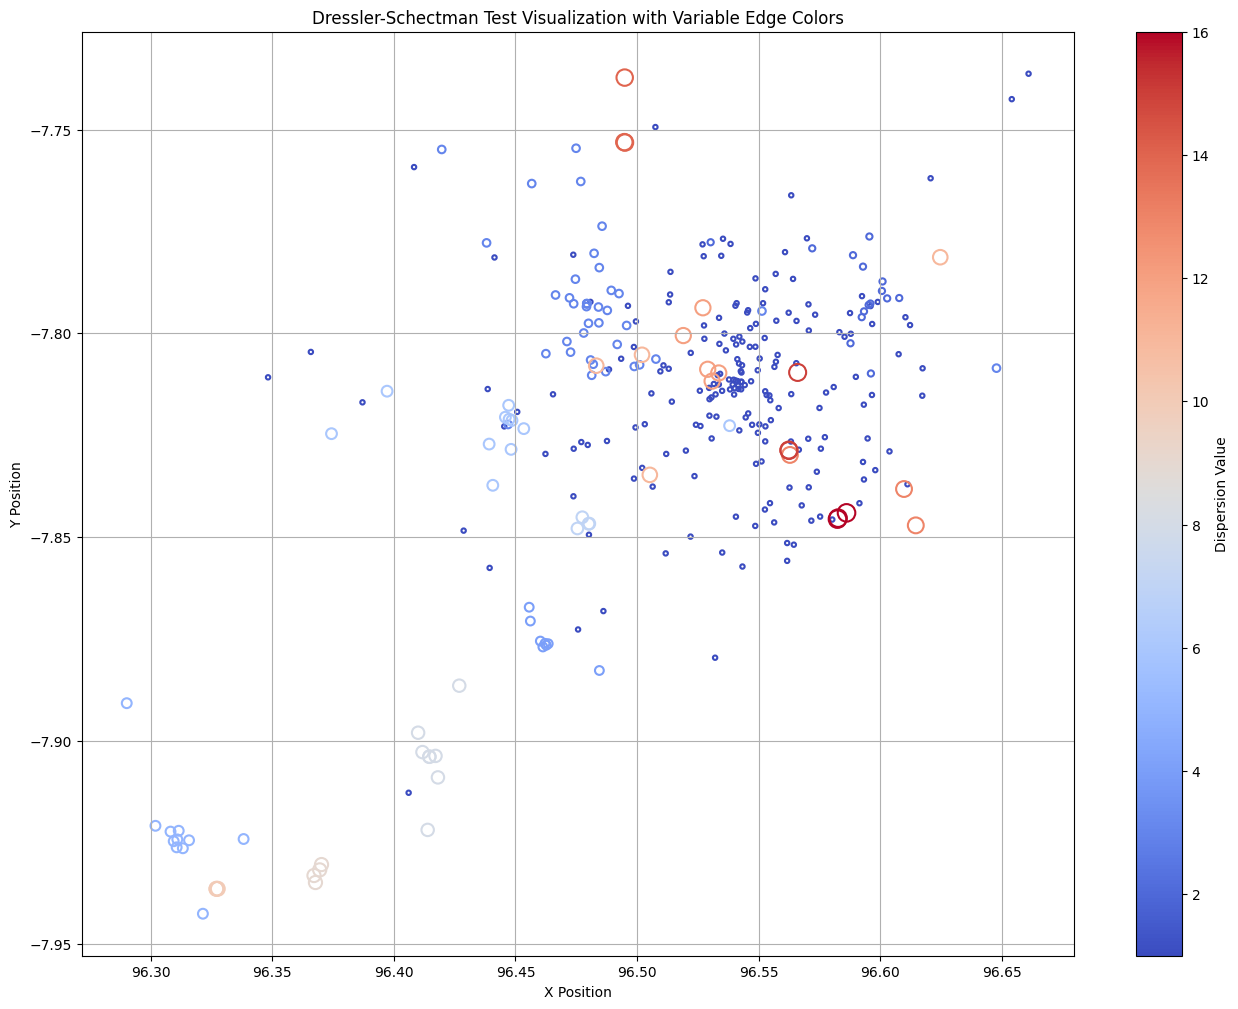

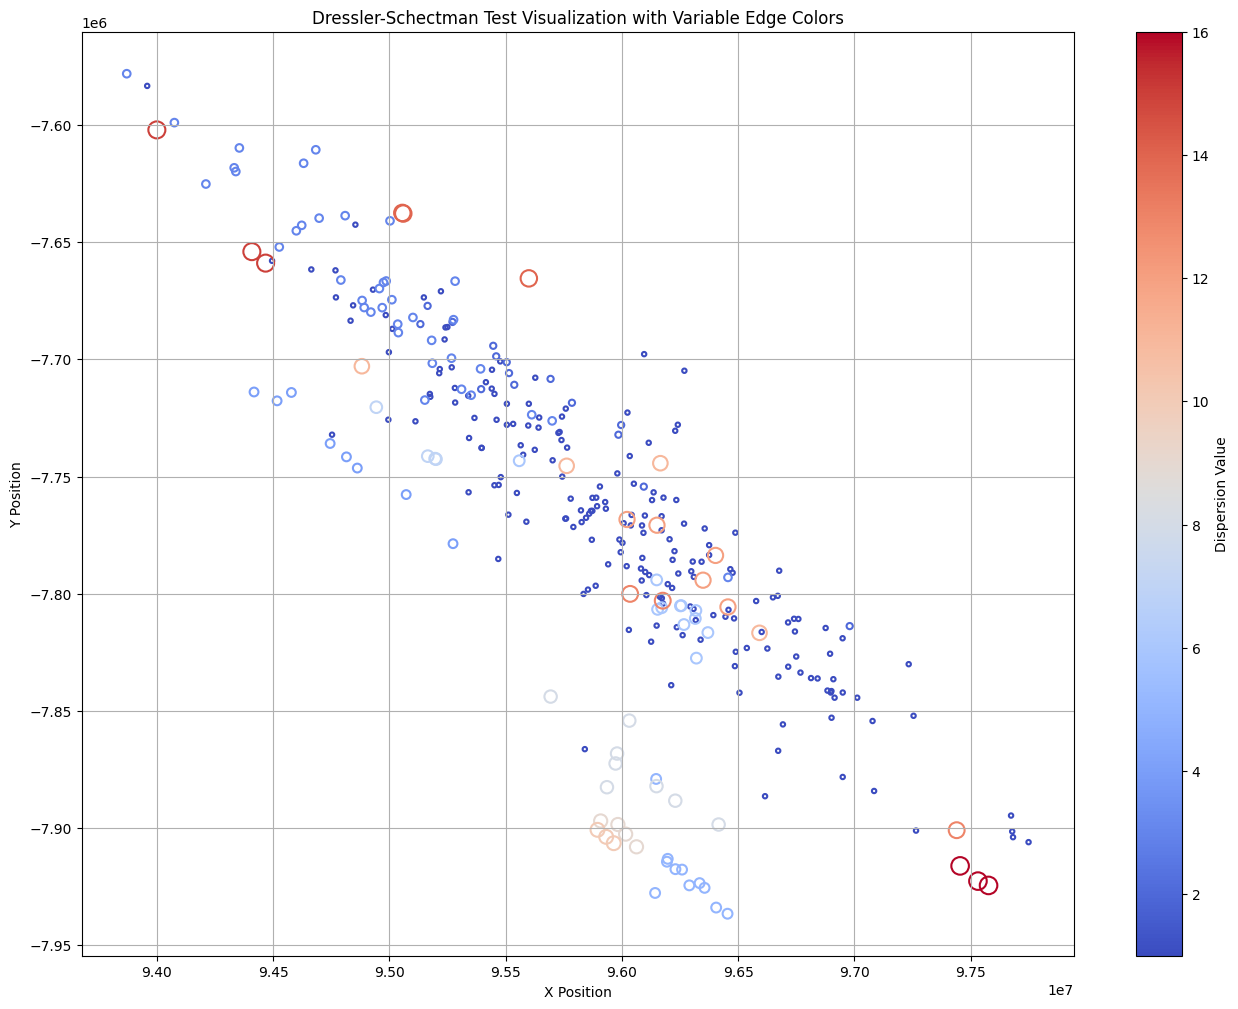

In [21]:

plotDS(X_data,Y_data,group+1,scale=10)
plotDS(X_Kpc,Y_Kpc,group+1,scale=10)

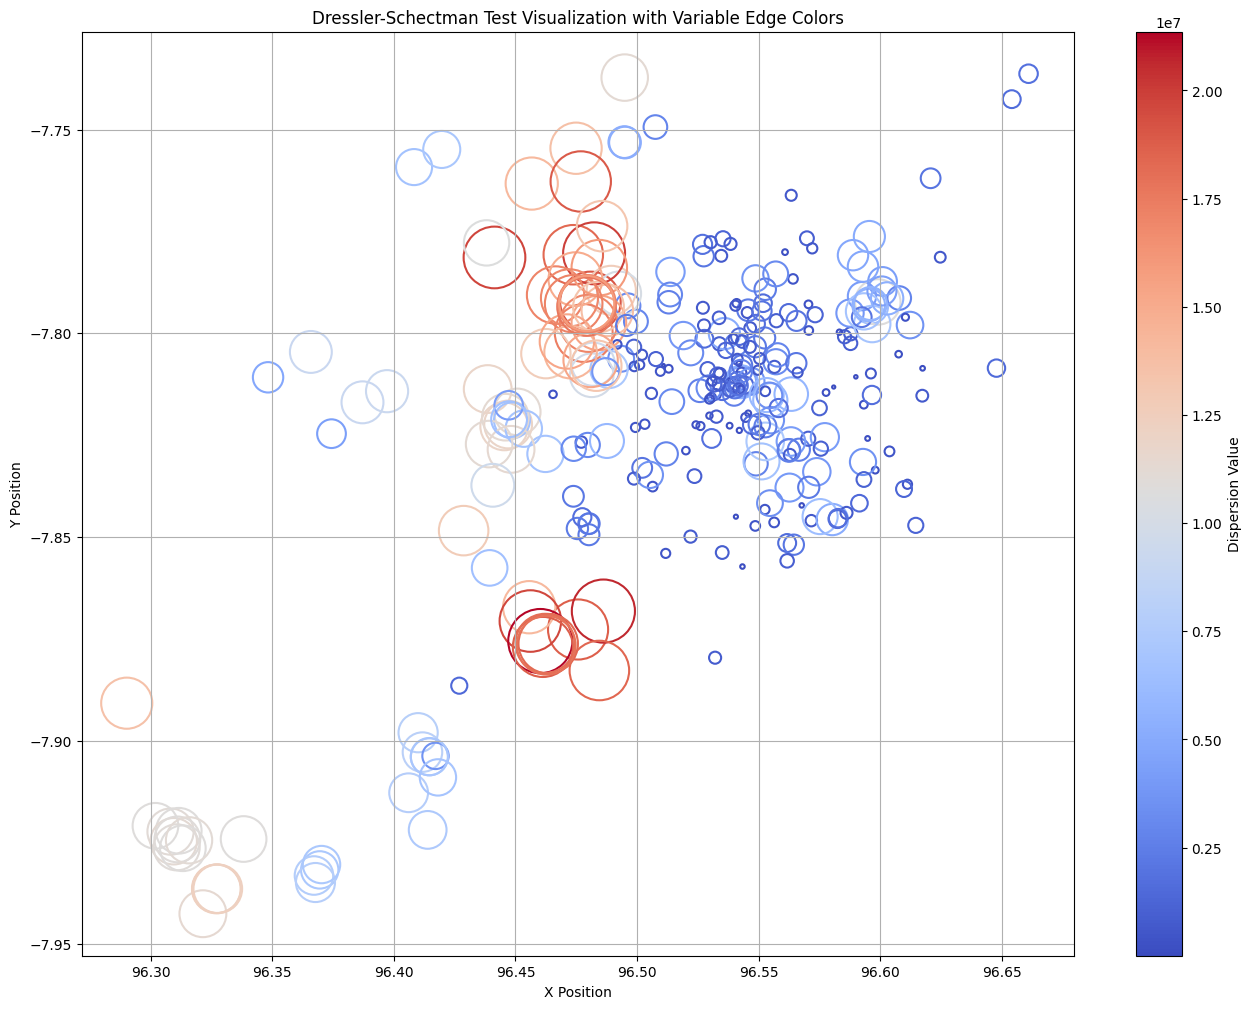

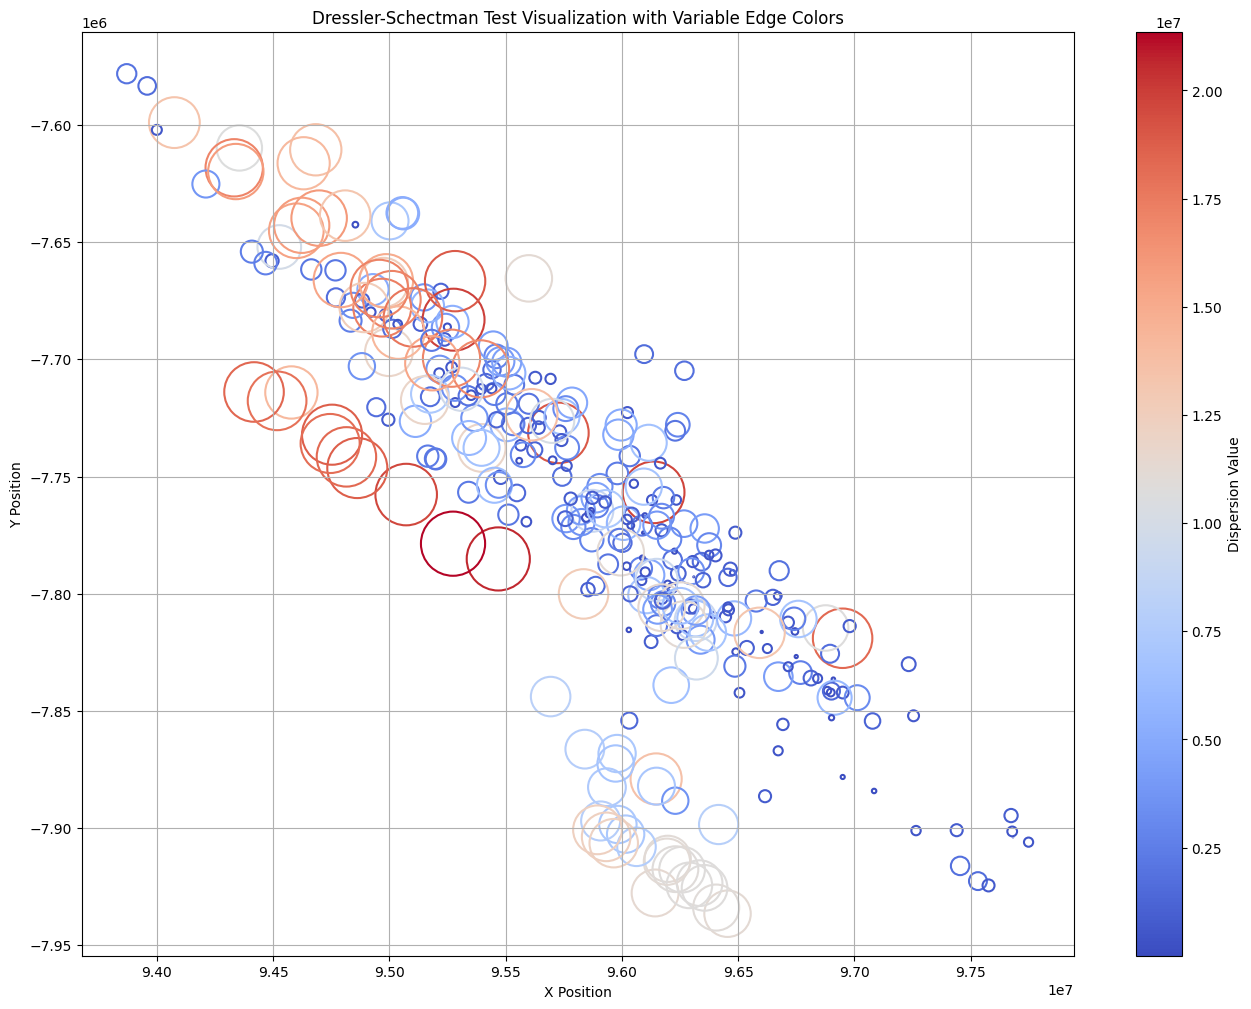

In [22]:

plotDS(X_data, Y_data, DS_deltas, scale=0.0001)
plotDS(X_Kpc, Y_Kpc, DS_deltas, scale=0.0001)

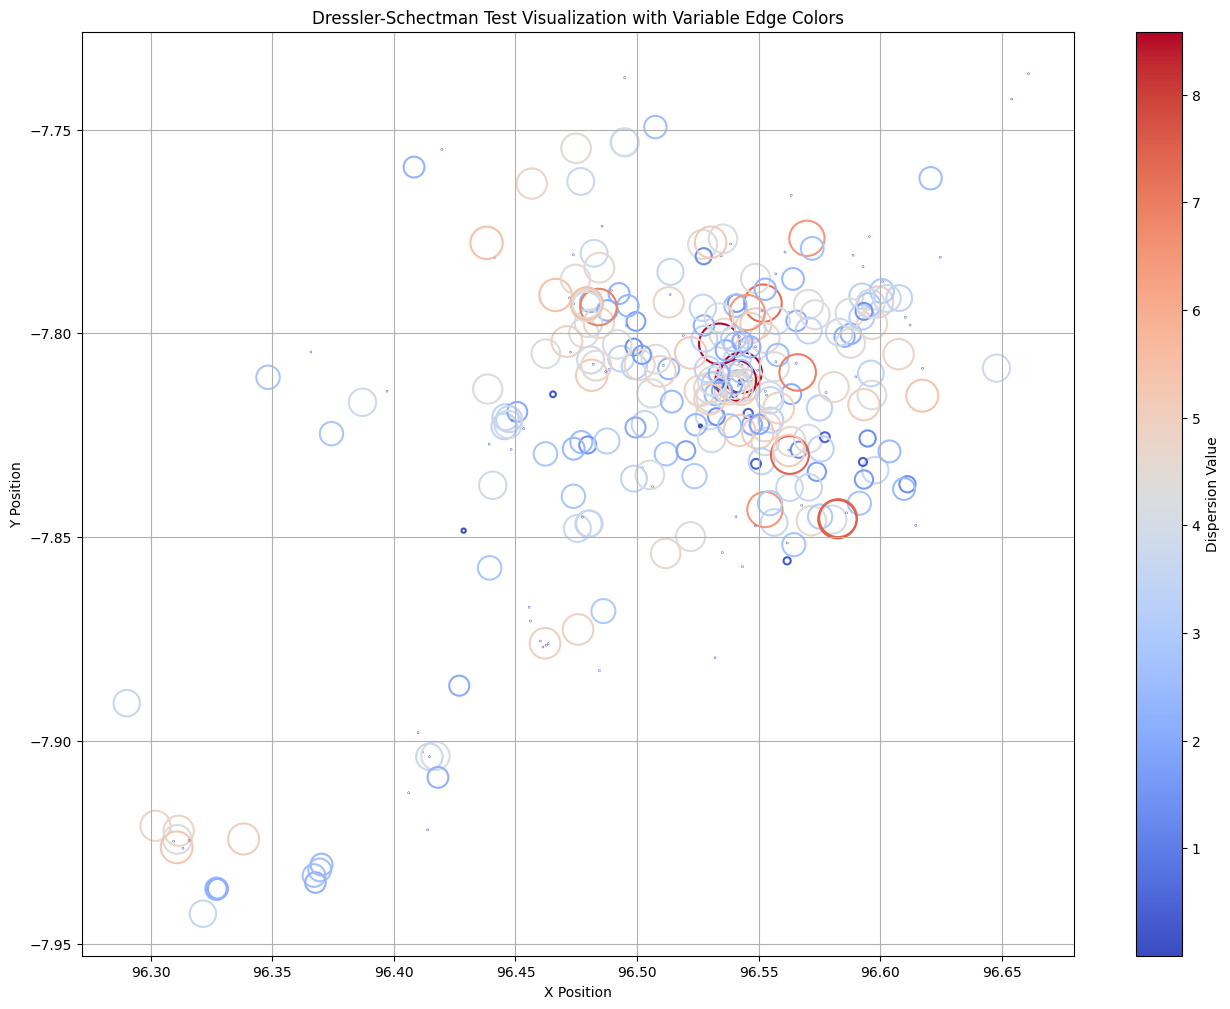

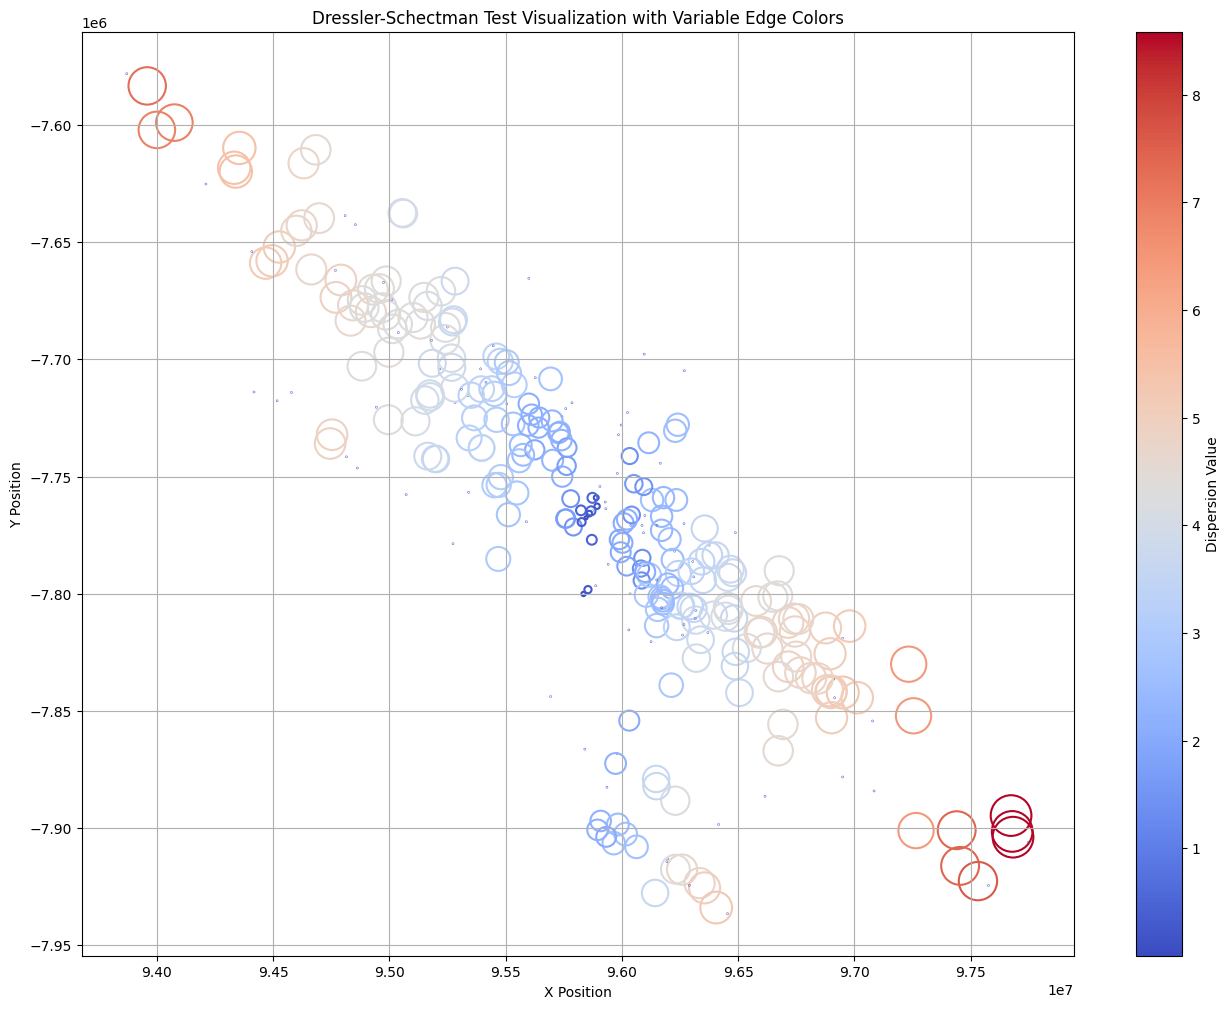

In [23]:

plotDS(X_data, Y_data, V_disp,scale=100);
plotDS(X_Kpc, Y_Kpc, V_disp,scale=100);

In [24]:
print(max(group))

15.0
